# Spatial Autocorrelation Analysis

This notebook investigates spatial patterns in reconstruction errors and latent dimensions:
1. Global spatial autocorrelation (Moran's I) of reconstruction errors
2. Local spatial autocorrelation (LISA) to identify error clusters
3. Spatial structure in latent dimensions (PCA vs Autoencoder)
4. Geographic comparison of method performance

In [1]:
import pandas as pd
import numpy as np
import geopandas as gpd
import matplotlib.pyplot as plt
from matplotlib import colors
from tqdm import tqdm
import os
import warnings
warnings.filterwarnings('ignore')

# Spatial statistics libraries
# Install if needed: pip install esda libpysal splot
from esda.moran import Moran, Moran_Local
from libpysal.weights import Queen
import splot
from splot.esda import plot_moran, moran_scatterplot, lisa_cluster

# CELL: Load from cache (skip slow computations if available)
import pickle

cache_dir = '../data/cache/'
use_cache = True  # Set to False to force recomputation

if use_cache and os.path.exists(f'{cache_dir}/gdf_with_errors.parquet'):
    print("=" * 70)
    print("LOADING FROM CACHE - Skipping slow computations!")
    print("=" * 70)

    # Load everything
    gdf = gpd.read_parquet(f'{cache_dir}/gdf_with_errors.parquet')

    with open(f'{cache_dir}/spatial_weights_queen.pkl', 'rb') as f:
        w = pickle.load(f)
    w.transform = 'R'

    df_original = pd.read_parquet(f'{cache_dir}/df_original_cached.parquet')

    print(f"✓ Loaded GeoDataFrame: {gdf.shape}")
    print(f"✓ Loaded spatial weights: {w.n} observations, {w.mean_neighbors:.2f} avg neighbors")
    print(f"✓ Loaded original data: {df_original.shape}")
    print("=" * 70)
    print("\nSKIP to the 'Global Moran's I' section below!")
    print("(Or set use_cache=False above to recompute everything)")
    print("=" * 70)

    CACHED = True
else:
    print("No cache found or use_cache=False - will compute everything...")
    CACHED = False

LOADING FROM CACHE - Skipping slow computations!
✓ Loaded GeoDataFrame: (188880, 17)
✓ Loaded spatial weights: 188880 observations, 5.98 avg neighbors
✓ Loaded original data: (188880, 408)

SKIP to the 'Global Moran's I' section below!
(Or set use_cache=False above to recompute everything)


## Configuration

In [2]:
# Analysis parameters (needed regardless of cache)
bottleneck_sizes = [2, 4, 8, 16, 32, 64, 100, 128]
data_path = "../AE_outputs/engcensus_all/"
working_dir = data_path + "250epoch_scan_lin"

# Paths
geo_path = "../data/geofiles/Output_Areas_(December_2021)_Boundaries_EW_BFE_(V9)_and_RUC.geojson"
cleaned_data_path = "../data/census_data/engcensus_cleaned_scaled.parquet"

# Output directory for this analysis
output_dir = "./plots/spatial_autocorr/"
os.makedirs(output_dir, exist_ok=True)

if not CACHED:
    print(f"Configuration loaded:")
    print(f"  Bottleneck sizes: {bottleneck_sizes}")
    print(f"  Working directory: {working_dir}")
    print(f"  Output directory: {output_dir}")

## Load Data

In [3]:
if not CACHED:
    # Load original census data
    print("Loading original census data...")
    df_original = pd.read_parquet(cleaned_data_path)
    df_original = df_original.set_index('OA')
    print(f"Original data shape: {df_original.shape}")

## Load Per-OA Reconstruction Errors

Quickly compute errors from pre-existing reconstructed outputs (same approach as notebook 4).

In [4]:
if not CACHED:

    # Load reconstructed outputs and compute per-OA errors
    print("Loading reconstructed outputs and computing per-OA errors...\n")

    # Store errors as DataFrames (one row per OA, one column per dimension)
    ae_errors = pd.DataFrame(index=df_original.index)
    pca_errors = pd.DataFrame(index=df_original.index)

    for n in tqdm(bottleneck_sizes, desc="Processing dimensions"):
        # Load PCA reconstruction
        pca_path = f"{data_path}PCA/{n}_components.csv"
        if os.path.exists(pca_path):
            pca_recon = pd.read_csv(pca_path, index_col="OA")
            pca_errors[f'dim_{n}'] = np.sqrt(np.mean((df_original - pca_recon) ** 2, axis=1)) * 100
        
        # Load Autoencoder reconstruction
        ae_path = f"{working_dir}/census_geodemo__bottleneck_{n}_v1__reconstructed_outputs.csv"
        if os.path.exists(ae_path):
            ae_recon = pd.read_csv(ae_path, index_col="ID")
            ae_errors[f'dim_{n}'] = np.sqrt(np.mean((df_original - ae_recon) ** 2, axis=1)) * 100

    print(f"\nLoaded errors for {len(ae_errors)} OAs across {len(bottleneck_sizes)} dimensions")
    print(f"AE errors shape: {ae_errors.shape}")
    print(f"PCA errors shape: {pca_errors.shape}")

In [5]:
if not CACHED:

    # Load OA geometries and merge with errors
    print("\nLoading OA geometries...")
    gdf = gpd.read_file(geo_path)
    gdf = gdf[['OA21CD', 'geometry']].rename(columns={'OA21CD': 'OA'})
    gdf = gdf.set_index('OA')

    # Merge errors with geometries
    gdf = gdf.join(ae_errors, rsuffix='_ae')
    gdf = gdf.join(pca_errors, rsuffix='_pca')

    print(f"GeoDataFrame shape: {gdf.shape}")
    print(f"Loaded {len(gdf)} Output Areas with geometry and errors")

## Create Spatial Weights Matrix

Defines neighborhood structure for spatial autocorrelation calculations.

In [6]:
if not CACHED:

    print("Creating spatial weights matrix (Queen contiguity)...")
    print("This may take a few minutes for ~180k OAs...")

    # Queen contiguity: OAs that share a border or vertex
    w = Queen.from_dataframe(gdf.reset_index())

    print(f"\nWeights matrix created:")
    print(f"  - Number of observations: {w.n}")
    print(f"  - Mean neighbors: {w.mean_neighbors:.2f}")
    print(f"  - Min neighbors: {w.min_neighbors}")
    print(f"  - Max neighbors: {w.max_neighbors}")

    # Row-standardize the weights
    w.transform = 'R'

In [7]:
import pickle

cache_dir = '../data/cache/'
os.makedirs(cache_dir, exist_ok=True)

print("Saving computed data for future runs...")

# Save the GeoDataFrame with all errors
gdf.to_parquet(f'{cache_dir}/gdf_with_errors.parquet')

# Save spatial weights
with open(f'{cache_dir}/spatial_weights_queen.pkl', 'wb') as f:
    pickle.dump(w, f)

# Save original data
df_original.to_parquet(f'{cache_dir}/df_original_cached.parquet')

print(f"✓ Saved GeoDataFrame: {gdf.shape}")
print(f"✓ Saved spatial weights: {w.n} observations")
print(f"✓ Saved original data: {df_original.shape}")
print(f"\nAll data cached in {cache_dir}")
print("Next time, run the 'LOAD FROM CACHE' cell at the top to skip the slow parts!")

Saving computed data for future runs...
✓ Saved GeoDataFrame: (188880, 17)
✓ Saved spatial weights: 188880 observations
✓ Saved original data: (188880, 408)

All data cached in ../data/cache/
Next time, run the 'LOAD FROM CACHE' cell at the top to skip the slow parts!


## Global Moran's I: Spatial Autocorrelation of Errors

Measures overall spatial clustering of reconstruction errors.
- Moran's I > 0: Positive spatial autocorrelation (similar values cluster)
- Moran's I ≈ 0: Random spatial pattern
- Moran's I < 0: Negative spatial autocorrelation (dissimilar values cluster)

In [8]:
# Compute Global Moran's I for all methods and dimensions
print("Computing Global Moran's I...\n")

morans_results = []

for n in tqdm(bottleneck_sizes, desc="Processing dimensions"):
    col_ae = f'dim_{n}'
    col_pca = f'dim_{n}_pca'
    
    if col_ae in gdf.columns:
        moran_ae = Moran(gdf[col_ae].values, w)
        morans_results.append({
            'dimension': n,
            'method': 'Autoencoder',
            'morans_i': moran_ae.I,
            'p_value': moran_ae.p_sim
        })
    
    if col_pca in gdf.columns:
        moran_pca = Moran(gdf[col_pca].values, w)
        morans_results.append({
            'dimension': n,
            'method': 'PCA',
            'morans_i': moran_pca.I,
            'p_value': moran_pca.p_sim
        })

morans_df = pd.DataFrame(morans_results)
print("\nGlobal Moran's I Results:")
print(morans_df.to_string())

# Save results for plotting later
data_dir = f"{output_dir}/data/"
os.makedirs(data_dir, exist_ok=True)
morans_df.to_csv(f"{data_dir}/global_morans.csv", index=False)
print(f"\n✓ Saved global Moran's I results to {data_dir}/global_morans.csv")

Computing Global Moran's I...



Processing dimensions: 100%|██████████| 8/8 [01:20<00:00, 10.01s/it]


Global Moran's I Results:
    dimension       method  morans_i  p_value
0           2  Autoencoder  0.419061    0.001
1           2          PCA  0.536227    0.001
2           4  Autoencoder  0.374281    0.001
3           4          PCA  0.515240    0.001
4           8  Autoencoder  0.319698    0.001
5           8          PCA  0.527606    0.001
6          16  Autoencoder  0.315424    0.001
7          16          PCA  0.467125    0.001
8          32  Autoencoder  0.356423    0.001
9          32          PCA  0.443675    0.001
10         64  Autoencoder  0.418166    0.001
11         64          PCA  0.457779    0.001
12        100  Autoencoder  0.449178    0.001
13        100          PCA  0.494423    0.001
14        128  Autoencoder  0.449660    0.001
15        128          PCA  0.494695    0.001

✓ Saved global Moran's I results to ./plots/spatial_autocorr//data//global_morans.csv


## Visualize Global Moran's I vs Dimension

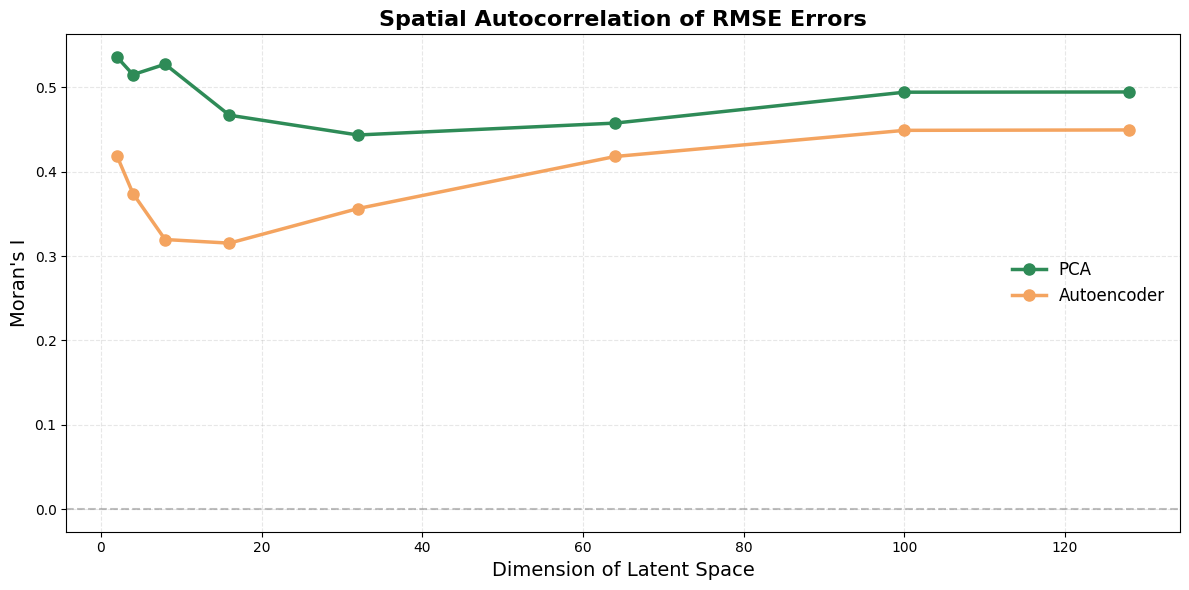


Interpretation:
- Higher Moran's I indicates stronger spatial clustering of errors
- Compare PCA vs Autoencoder: which produces more spatially structured errors?


In [9]:
# Load global Moran's I results if not in memory
if 'morans_df' not in locals():
    data_dir = f"{output_dir}/data/"
    morans_df = pd.read_csv(f"{data_dir}/global_morans.csv")
    print(f"✓ Loaded global Moran's I results from {data_dir}/global_morans.csv")

# Plot Moran's I vs dimension
fig, ax = plt.subplots(figsize=(12, 6))

colors_dict = {'PCA': 'seagreen', 'Autoencoder': 'sandybrown'}

for method in ['PCA', 'Autoencoder']:
    subset = morans_df[morans_df['method'] == method]
    ax.plot(
        subset['dimension'], 
        subset['morans_i'],
        marker='o', 
        markersize=8, 
        linewidth=2.5,
        label=method,
        color=colors_dict[method]
    )

ax.axhline(y=0, color='gray', linestyle='--', alpha=0.5)
ax.set_xlabel('Dimension of Latent Space', fontsize=14)
ax.set_ylabel("Moran's I", fontsize=14)
ax.set_title("Spatial Autocorrelation of RMSE Errors", fontsize=16, fontweight='bold')
ax.legend(fontsize=12, frameon=False)
ax.grid(True, linestyle='--', alpha=0.3)

plt.tight_layout()
plt.savefig(f"{output_dir}/global_morans_i_vs_dimension.png", dpi=300, bbox_inches='tight')
plt.show()

print("\nInterpretation:")
print("- Higher Moran's I indicates stronger spatial clustering of errors")
print("- Compare PCA vs Autoencoder: which produces more spatially structured errors?")

## Local Moran's I (LISA): Identify Error Clusters

Identifies specific geographic clusters of high/low errors:
- **HH (High-High)**: High error OAs surrounded by high error neighbors
- **LL (Low-Low)**: Low error OAs surrounded by low error neighbors
- **HL (High-Low)**: High error OAs surrounded by low error neighbors (outliers)
- **LH (Low-High)**: Low error OAs surrounded by high error neighbors (outliers)

In [10]:
# Compute LISA for selected dimensions
dimensions_to_map = [100]  # Low, medium, high dimensional


lisa_results = {}

print("Computing Local Moran's I (LISA)...\n")

for method, suffix in [('PCA', '_pca'), ('Autoencoder', '')]:
    lisa_results[method] = {}
    
    for n in dimensions_to_map:
        col = f'dim_{n}{suffix}'
        if col not in gdf.columns:
            continue
        
        lisa = Moran_Local(gdf[col].values, w)
        lisa_results[method][n] = lisa
        
        print(f"{method} - {n} dimensions:")
        print(f"  Significant clusters (p<0.05): {(lisa.p_sim < 0.05).sum()} OAs")
        print(f"  HH clusters: {((lisa.q == 1) & (lisa.p_sim < 0.05)).sum()}")
        print(f"  LL clusters: {((lisa.q == 3) & (lisa.p_sim < 0.05)).sum()}")
        print()

# Save LISA results for plotting later
import pickle
data_dir = f"{output_dir}/data/"
os.makedirs(data_dir, exist_ok=True)
with open(f"{data_dir}/lisa_results.pkl", 'wb') as f:
    pickle.dump(lisa_results, f)
print(f"✓ Saved LISA results to {data_dir}/lisa_results.pkl")

Computing Local Moran's I (LISA)...

PCA - 100 dimensions:
  Significant clusters (p<0.05): 67609 OAs
  HH clusters: 23313
  LL clusters: 38624

Autoencoder - 100 dimensions:
  Significant clusters (p<0.05): 65746 OAs
  HH clusters: 23355
  LL clusters: 36109

✓ Saved LISA results to ./plots/spatial_autocorr//data//lisa_results.pkl


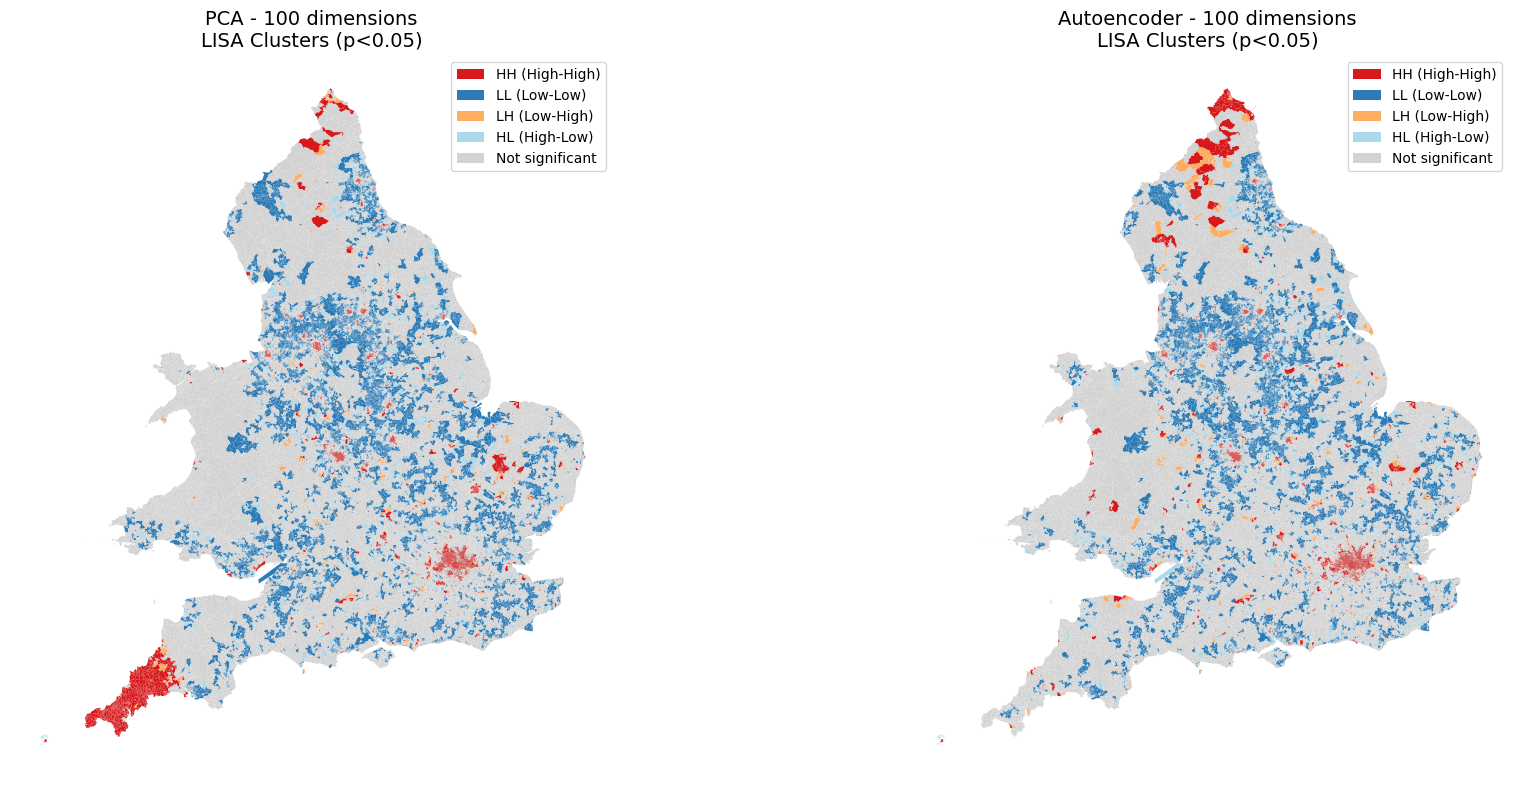

In [11]:
# Load LISA results if not in memory
if 'lisa_results' not in locals():
    import pickle
    data_dir = f"{output_dir}/data/"
    with open(f"{data_dir}/lisa_results.pkl", 'rb') as f:
        lisa_results = pickle.load(f)
    print(f"✓ Loaded LISA results from {data_dir}/lisa_results.pkl")

# Ensure dimensions_to_map is defined
if 'dimensions_to_map' not in locals():
    dimensions_to_map = [100]

# Create cluster maps for each dimension
for n in dimensions_to_map:
    fig, axes = plt.subplots(1, 2, figsize=(20, 8))
    
    for idx, method in enumerate(['PCA', 'Autoencoder']):
        if n not in lisa_results[method]:
            continue
        
        ax = axes[idx]
        lisa = lisa_results[method][n]
        
        # Prepare data for mapping
        gdf_plot = gdf.reset_index()[['OA', 'geometry']].copy()
        gdf_plot['cluster'] = lisa.q
        gdf_plot['significant'] = lisa.p_sim < 0.05
        
        # Only show significant clusters
        gdf_plot.loc[~gdf_plot['significant'], 'cluster'] = 0
        
        # Cluster colors
        cluster_colors = {
            0: 'lightgray',
            1: '#d7191c',  # HH - red
            2: '#fdae61',  # LH - light red/orange
            3: '#2c7bb6',  # LL - blue
            4: '#abd9e9'   # HL - light blue
        }
        
        gdf_plot['color'] = gdf_plot['cluster'].map(cluster_colors)
        gdf_plot.plot(color=gdf_plot['color'], ax=ax, linewidth=0, edgecolor='none')
        
        ax.set_title(f"{method} - {n} dimensions\nLISA Clusters (p<0.05)", fontsize=14)
        ax.axis('off')
        
        # Add legend
        from matplotlib.patches import Patch
        legend_elements = [
            Patch(facecolor='#d7191c', label='HH (High-High)'),
            Patch(facecolor='#2c7bb6', label='LL (Low-Low)'),
            Patch(facecolor='#fdae61', label='LH (Low-High)'),
            Patch(facecolor='#abd9e9', label='HL (High-Low)'),
            Patch(facecolor='lightgray', label='Not significant')
        ]
        ax.legend(handles=legend_elements, loc='upper right', fontsize=10)
    
    plt.tight_layout()
    plt.savefig(f"{output_dir}/lisa_clusters_{n}d.png", dpi=300, bbox_inches='tight')
    plt.show()

## Spatial Patterns in Error Differences (AE vs PCA)

Where does the autoencoder outperform PCA, and vice versa?

In [12]:
# Compute error difference (AE - PCA) for each dimension using percentage difference
print("Computing spatial autocorrelation of error differences (percentage)...\n")

error_diff_morans = []

for n in bottleneck_sizes:
    col_ae = f'dim_{n}'
    col_pca = f'dim_{n}_pca'
    
    if col_ae not in gdf.columns or col_pca not in gdf.columns:
        continue
    
    # Percentage difference: (AE - PCA) / PCA * 100 (as in notebook 4)
    perc_diff = (gdf[col_ae] - gdf[col_pca]) / gdf[col_pca] * 100
    
    # Moran's I of the percentage difference
    moran_diff = Moran(perc_diff.values, w)
    
    error_diff_morans.append({
        'dimension': n,
        'morans_i': moran_diff.I,
        'p_value': moran_diff.p_sim,
        'mean_perc_diff': perc_diff.mean(),
        'pct_ae_better': (perc_diff < 0).sum() / len(perc_diff) * 100
    })
    
    print(f"{n}d - Mean % diff (AE-PCA)/PCA: {perc_diff.mean():.4f}%, "
          f"AE better: {error_diff_morans[-1]['pct_ae_better']:.1f}%, "
          f"Moran's I: {moran_diff.I:.4f}")

diff_morans_df = pd.DataFrame(error_diff_morans)

# Save results for plotting later
data_dir = f"{output_dir}/data/"
os.makedirs(data_dir, exist_ok=True)
diff_morans_df.to_csv(f"{data_dir}/error_diff_morans.csv", index=False)
print(f"\n✓ Saved error difference Moran's I results to {data_dir}/error_diff_morans.csv")

Computing spatial autocorrelation of error differences (percentage)...

2d - Mean % diff (AE-PCA)/PCA: -23.6426%, AE better: 90.3%, Moran's I: 0.3003
4d - Mean % diff (AE-PCA)/PCA: -25.3097%, AE better: 93.3%, Moran's I: 0.3323
8d - Mean % diff (AE-PCA)/PCA: -25.9852%, AE better: 96.9%, Moran's I: 0.3857
16d - Mean % diff (AE-PCA)/PCA: -23.1130%, AE better: 98.5%, Moran's I: 0.3105
32d - Mean % diff (AE-PCA)/PCA: -18.5096%, AE better: 98.3%, Moran's I: 0.2944
64d - Mean % diff (AE-PCA)/PCA: -14.8545%, AE better: 97.7%, Moran's I: 0.2845
100d - Mean % diff (AE-PCA)/PCA: -9.7089%, AE better: 93.1%, Moran's I: 0.3141
128d - Mean % diff (AE-PCA)/PCA: 9.9346%, AE better: 10.6%, Moran's I: 0.2433

✓ Saved error difference Moran's I results to ./plots/spatial_autocorr//data//error_diff_morans.csv


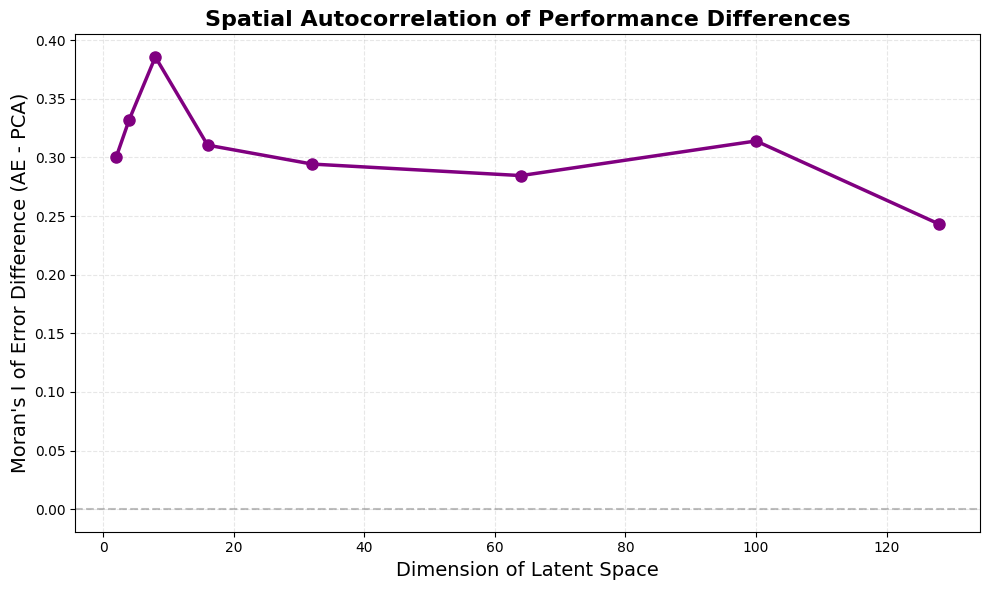


Interpretation:
- Positive Moran's I: Performance differences are spatially clustered
- This suggests geographic regions where one method consistently outperforms the other


In [13]:
# Load error difference Moran's I results if not in memory
if 'diff_morans_df' not in locals():
    data_dir = f"{output_dir}/data/"
    diff_morans_df = pd.read_csv(f"{data_dir}/error_diff_morans.csv")
    print(f"✓ Loaded error difference Moran's I results from {data_dir}/error_diff_morans.csv")

# Plot Moran's I of error differences
fig, ax = plt.subplots(figsize=(10, 6))

ax.plot(
    diff_morans_df['dimension'],
    diff_morans_df['morans_i'],
    marker='o',
    markersize=8,
    linewidth=2.5,
    color='purple'
)

ax.axhline(y=0, color='gray', linestyle='--', alpha=0.5)
ax.set_xlabel('Dimension of Latent Space', fontsize=14)
ax.set_ylabel("Moran's I of Error Difference (AE - PCA)", fontsize=14)
ax.set_title("Spatial Autocorrelation of Performance Differences", fontsize=16, fontweight='bold')
ax.grid(True, linestyle='--', alpha=0.3)

plt.tight_layout()
plt.savefig(f"{output_dir}/morans_i_error_difference.png", dpi=300, bbox_inches='tight')
plt.show()

print("\nInterpretation:")
print("- Positive Moran's I: Performance differences are spatially clustered")
print("- This suggests geographic regions where one method consistently outperforms the other")

## Spatial Autocorrelation in Latent Dimensions

Do the learned latent dimensions themselves show spatial structure?

In [14]:
# Load latent representations for a selected dimension
target_dim = 100

print(f"Analyzing spatial autocorrelation of {target_dim}-dimensional latent space...\n")

# Load PCA components
from sklearn.decomposition import PCA

pca = PCA(n_components=target_dim)
pca_latent = pca.fit_transform(df_original)
pca_latent_df = pd.DataFrame(pca_latent, index=df_original.index)

# Load AE latent space
ae_latent_path = f"{working_dir}/census_geodemo__bottleneck_{target_dim}_v1__latent.csv"
if os.path.exists(ae_latent_path):
    ae_latent_df = pd.read_csv(ae_latent_path, index_col="OA")
    ae_latent_df = ae_latent_df.reindex(df_original.index)
    print(f"AE latent shape: {ae_latent_df.shape}")
else:
    print(f"Warning: AE latent file not found at {ae_latent_path}")
    ae_latent_df = None

print(f"PCA latent shape: {pca_latent_df.shape}")

Analyzing spatial autocorrelation of 100-dimensional latent space...

AE latent shape: (188880, 100)
PCA latent shape: (188880, 100)


In [15]:
data_dir = f"{output_dir}/data/"
if use_cache and os.path.exists(f"{data_dir}/latent_morans.csv"):
    latent_morans_df = pd.read_csv(f"{data_dir}/latent_morans.csv")
    print(f"✓ Loaded latent Moran's I results from {data_dir}/latent_morans.csv")
else:
    # Compute Moran's I for each latent dimension
    print("Computing Moran's I for each latent dimension...\n")
    latent_morans = []
    
    # PCA
    for i in tqdm(range(target_dim), desc="PCA dimensions"):
        moran = Moran(pca_latent_df.iloc[:, i].values, w)
        latent_morans.append({
            'dimension_idx': i,
            'method': 'PCA',
            'morans_i': moran.I,
            'p_value': moran.p_sim
        })

    # Autoencoder
    if ae_latent_df is not None:
        for i in tqdm(range(target_dim), desc="AE dimensions"):
            moran = Moran(ae_latent_df.iloc[:, i].values, w)
            latent_morans.append({
                'dimension_idx': i,
                'method': 'Autoencoder',
                'morans_i': moran.I,
                'p_value': moran.p_sim
            })

    latent_morans_df = pd.DataFrame(latent_morans)

    # Save results for plotting later
    os.makedirs(data_dir, exist_ok=True)
    latent_morans_df.to_csv(f"{data_dir}/latent_morans.csv", index=False)
    print(f"\n✓ Saved latent Moran's I results to {data_dir}/latent_morans.csv")


✓ Loaded latent Moran's I results from ./plots/spatial_autocorr//data//latent_morans.csv


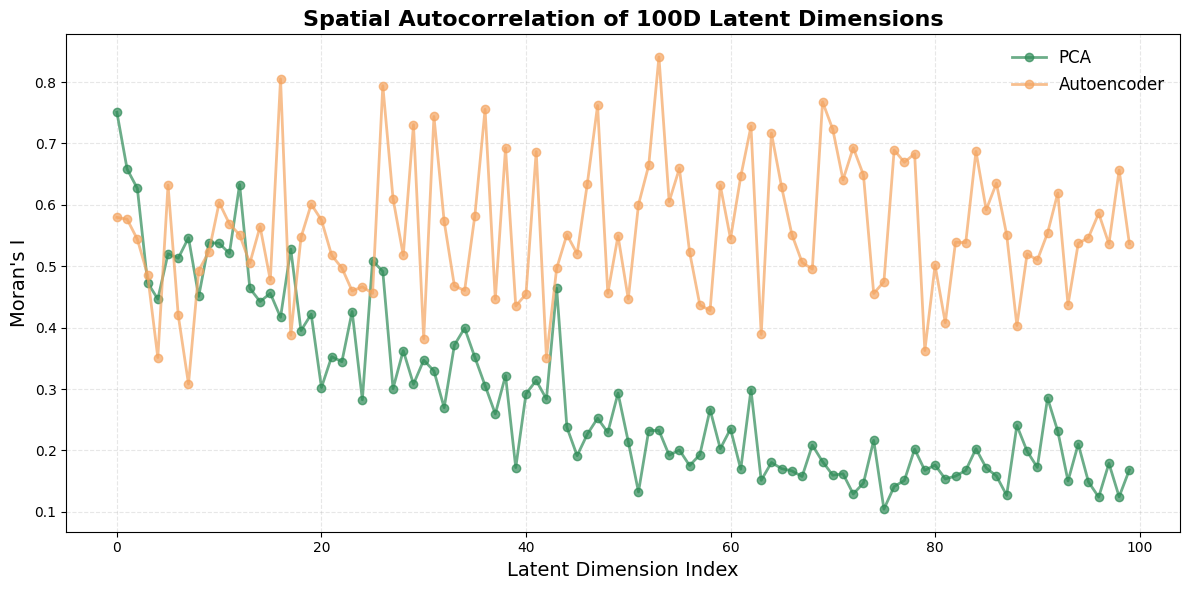


Interpretation:
- Compare which method produces more/less spatially structured latent dimensions
- Higher Moran's I = that latent dimension captures geographic patterns
- Lower Moran's I = that latent dimension captures non-spatial variation


In [16]:

# Plot Moran's I for each latent dimension
fig, ax = plt.subplots(figsize=(12, 6))

for method in ['PCA', 'Autoencoder']:
    subset = latent_morans_df[latent_morans_df['method'] == method]
    if len(subset) == 0:
        continue
    color = 'seagreen' if method == 'PCA' else 'sandybrown'
    ax.plot(
        subset['dimension_idx'],
        subset['morans_i'],
        marker='o',
        markersize=6,
        linewidth=2,
        label=method,
        color=color,
        alpha=0.7
    )

ax.set_xlabel('Latent Dimension Index', fontsize=14)
ax.set_ylabel("Moran's I", fontsize=14)
ax.set_title(f"Spatial Autocorrelation of {target_dim}D Latent Dimensions", fontsize=16, fontweight='bold')
ax.legend(fontsize=12, frameon=False)
ax.grid(True, linestyle='--', alpha=0.3)

plt.tight_layout()
plt.savefig(f"{output_dir}/latent_morans_i_{target_dim}d.png", dpi=300, bbox_inches='tight')
plt.show()

print("\nInterpretation:")
print("- Compare which method produces more/less spatially structured latent dimensions")
print("- Higher Moran's I = that latent dimension captures geographic patterns")
print("- Lower Moran's I = that latent dimension captures non-spatial variation")

## LISA Maps for Latent Dimensions

Maps showing which latent dimensions capture geographic patterns (ranked by spatial autocorrelation).

In [ ]:
# Load latent Moran's I results if not in memory
if 'latent_morans_df' not in locals():
    data_dir = f"{output_dir}/data/"
    latent_morans_df = pd.read_csv(f"{data_dir}/latent_morans.csv")
    print(f"✓ Loaded latent Moran's I results from {data_dir}/latent_morans.csv")

# Create LISA maps for latent dimensions (using already-computed Moran's I)
n_dims_to_map = 100  # Top N most spatial dimensions to map

# Create output subdirectories
latent_lisa_dir = f"{output_dir}/latent_lisa/"
os.makedirs(latent_lisa_dir, exist_ok=True)

print("="*80)
print(f"CREATING LISA MAPS FOR LATENT DIMENSIONS ({target_dim}D)")
print("="*80)

# Get top N most spatial dimensions (already computed in latent_morans_df!)
pca_dims = latent_morans_df[latent_morans_df['method'] == 'PCA'].sort_values('morans_i', ascending=False)
top_pca_dims = pca_dims.head(n_dims_to_map)['dimension_idx'].values

if ae_latent_df is not None:
    ae_dims = latent_morans_df[latent_morans_df['method'] == 'Autoencoder'].sort_values('morans_i', ascending=False)
    top_ae_dims = ae_dims.head(n_dims_to_map)['dimension_idx'].values
else:
    top_ae_dims = []

print(f"\nMost spatial PCA dimensions (top 10):")
for i, idx in enumerate(top_pca_dims[:10], 1):
    mi = pca_dims[pca_dims['dimension_idx'] == idx]['morans_i'].values[0]
    print(f"  #{i}: Dim {idx} (Moran's I = {mi:.4f})")

if len(top_ae_dims) > 0:
    print(f"\nMost spatial AE dimensions (top 10):")
    for i, idx in enumerate(top_ae_dims[:10], 1):
        mi = ae_dims[ae_dims['dimension_idx'] == idx]['morans_i'].values[0]
        print(f"  #{i}: Dim {idx} (Moran's I = {mi:.4f})")

# Save rankings to CSV
pca_dims.to_csv(f"{latent_lisa_dir}/pca_ranking_{target_dim}d.csv", index=False)
if len(top_ae_dims) > 0:
    ae_dims.to_csv(f"{latent_lisa_dir}/ae_ranking_{target_dim}d.csv", index=False)
print(f"\n✓ Saved rankings to {latent_lisa_dir}")

CREATING LISA MAPS FOR LATENT DIMENSIONS (100D)

Most spatial PCA dimensions (top 10):
  #1: Dim 0 (Moran's I = 0.7507)
  #2: Dim 1 (Moran's I = 0.6583)
  #3: Dim 12 (Moran's I = 0.6332)
  #4: Dim 2 (Moran's I = 0.6268)
  #5: Dim 7 (Moran's I = 0.5465)
  #6: Dim 9 (Moran's I = 0.5385)
  #7: Dim 10 (Moran's I = 0.5375)
  #8: Dim 17 (Moran's I = 0.5279)
  #9: Dim 11 (Moran's I = 0.5209)
  #10: Dim 5 (Moran's I = 0.5204)

Most spatial AE dimensions (top 10):
  #1: Dim 53 (Moran's I = 0.8410)
  #2: Dim 16 (Moran's I = 0.8052)
  #3: Dim 26 (Moran's I = 0.7941)
  #4: Dim 69 (Moran's I = 0.7678)
  #5: Dim 47 (Moran's I = 0.7619)
  #6: Dim 36 (Moran's I = 0.7556)
  #7: Dim 31 (Moran's I = 0.7440)
  #8: Dim 29 (Moran's I = 0.7306)
  #9: Dim 62 (Moran's I = 0.7278)
  #10: Dim 70 (Moran's I = 0.7229)

✓ Saved rankings to ./plots/spatial_autocorr//latent_lisa/


: 

In [ ]:
import gc
from tqdm import tqdm

def compute_lisa(dim_idx, latent_df, dims_df, method, rank, output_dir, oa_codes, w):
    """Compute LISA and save to CSV only"""
    mi = dims_df[dims_df['dimension_idx'] == dim_idx]['morans_i'].values[0]
    latent_values = latent_df.iloc[:, dim_idx].values
    
    lisa = Moran_Local(latent_values, w, permutations=99)
    
    significant = lisa.p_sim < 0.05
    clusters = lisa.q.copy()
    clusters[~significant] = 0
    
    cluster_labels = {0: 'Not sig', 1: 'HH', 2: 'LH', 3: 'LL', 4: 'HL'}
    
    df = pd.DataFrame({
        'OA': oa_codes,
        'value': latent_values,
        'local_i': lisa.Is,
        'p_value': lisa.p_sim,
        'cluster': clusters,
        'cluster_label': [cluster_labels[c] for c in clusters],
        'morans_i': mi
    })
    
    df.to_csv(f"{output_dir}/{method.lower()}_dim{dim_idx:02d}_rank{rank:02d}.csv", index=False)
    
    n_sig = significant.sum()
    
    del lisa, df, latent_values, clusters, significant
    gc.collect()
    
    return n_sig

# Setup
oa_codes = gdf.reset_index()['OA'].values

if ae_latent_df is not None and len(top_ae_dims) > 0:
    print("\nProcessing AE dimensions...")
    for rank, dim_idx in enumerate(tqdm(top_ae_dims), 1):
        n_sig = compute_lisa(dim_idx, ae_latent_df, ae_dims, 'AE', rank, latent_lisa_dir, oa_codes, w)

print("\nProcessing PCA dimensions...")
for rank, dim_idx in enumerate(tqdm(top_pca_dims), 1):
    n_sig = compute_lisa(dim_idx, pca_latent_df, pca_dims, 'PCA', rank, latent_lisa_dir, oa_codes, w)

print(f"\n✓ All CSVs saved to {latent_lisa_dir}")


Processing PCA dimensions...


  2%|▏         | 2/100 [02:13<1:48:09, 66.22s/it]

In [ ]:
import glob
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

def plot_lisa(csv_path, base_gdf, output_dir):
    """Load CSV and plot LISA map"""
    df = pd.read_csv(csv_path)
    
    # Merge with geometry
    gdf_plot = base_gdf.merge(df, on='OA')
    
    # Colours
    cluster_colors = {0: 'lightgray', 1: '#d7191c', 2: '#fdae61', 3: '#2c7bb6', 4: '#abd9e9'}
    colors = gdf_plot['cluster'].map(cluster_colors)
    
    # Extract info for title from filename
    filename = os.path.basename(csv_path).replace('.csv', '')
    mi = df['morans_i'].iloc[0]
    n_sig = (df['cluster'] != 0).sum()
    
    fig, ax = plt.subplots(figsize=(10, 10))
    gdf_plot.plot(color=colors, ax=ax, linewidth=0, edgecolor='none')
    
    ax.set_title(f"{filename}\nMoran's I = {mi:.4f} | {n_sig:,} significant", fontsize=12)
    ax.axis('off')
    
    legend = [
        Patch(facecolor='#d7191c', label='HH'), 
        Patch(facecolor='#2c7bb6', label='LL'),
        Patch(facecolor='#fdae61', label='LH'), 
        Patch(facecolor='#abd9e9', label='HL'),
        Patch(facecolor='lightgray', label='Not sig')
    ]
    ax.legend(handles=legend, loc='lower left', fontsize=9)
    
    plt.savefig(f"{output_dir}/{filename}.png", dpi=300, bbox_inches='tight')
    plt.close('all')
    
    del gdf_plot, df, colors
    gc.collect()

# Setup
base_gdf = gdf.reset_index()[['OA', 'geometry']].copy()

# Plot all CSVs
csv_files = sorted(glob.glob(f"{latent_lisa_dir}/*.csv"))
print(f"Plotting {len(csv_files)} maps...")

for csv_path in tqdm(csv_files):
    plot_lisa(csv_path, base_gdf, latent_lisa_dir)

print(f"\n✓ All maps saved to {latent_lisa_dir}")

## Summary Statistics

In [ ]:
# Load all results if not in memory
data_dir = f"{output_dir}/data/"
if 'morans_df' not in locals():
    morans_df = pd.read_csv(f"{data_dir}/global_morans.csv")
if 'diff_morans_df' not in locals():
    diff_morans_df = pd.read_csv(f"{data_dir}/error_diff_morans.csv")
if 'latent_morans_df' not in locals():
    latent_morans_df = pd.read_csv(f"{data_dir}/latent_morans.csv")

print("="*80)
print("SPATIAL AUTOCORRELATION ANALYSIS SUMMARY")
print("="*80)

print("\n1. GLOBAL MORAN'S I (RMSE Errors):")
print("-" * 80)
pivot = morans_df.pivot_table(index='dimension', columns='method', values='morans_i')
print(pivot)

print("\n2. MEAN MORAN'S I BY METHOD:")
print("-" * 80)
mean_morans = morans_df.groupby('method')['morans_i'].agg(['mean', 'std'])
print(mean_morans)

print("\n3. LATENT DIMENSION SPATIAL STRUCTURE:")
print("-" * 80)
latent_summary = latent_morans_df.groupby('method')['morans_i'].agg(['mean', 'std', 'min', 'max'])
print(latent_summary)

print("\n4. ERROR DIFFERENCE (AE - PCA) SPATIAL CLUSTERING:")
print("-" * 80)
print(diff_morans_df[['dimension', 'mean_perc_diff', 'pct_ae_better', 'morans_i']])

print("\n" + "="*80)
print(f"Analysis complete! Plots saved to: {output_dir}")
print("="*80)